In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Shift index to start from 1 instead of 0
df.index = df.index + 1

# Check the first few rows again
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check dimensions
print("Dataset Shape:", df.shape)
print("=" * 40)

# Check data types and missing values
df.info()

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 1 to 7043
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [5]:
# Convert empty spaces in TotalCharges to NaN and convert column to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill missing TotalCharges values with 0 (since tenure is 0 for these new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Map SeniorCitizen from 0/1 to No/Yes for better visualization
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Drop customerID column as it is not needed for analysis
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Verify missing values after cleaning
print("Missing values in dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNew DataFrame Info:")
df.info()

Missing values in dataset:
Series([], dtype: int64)

New DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 1 to 7043
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling

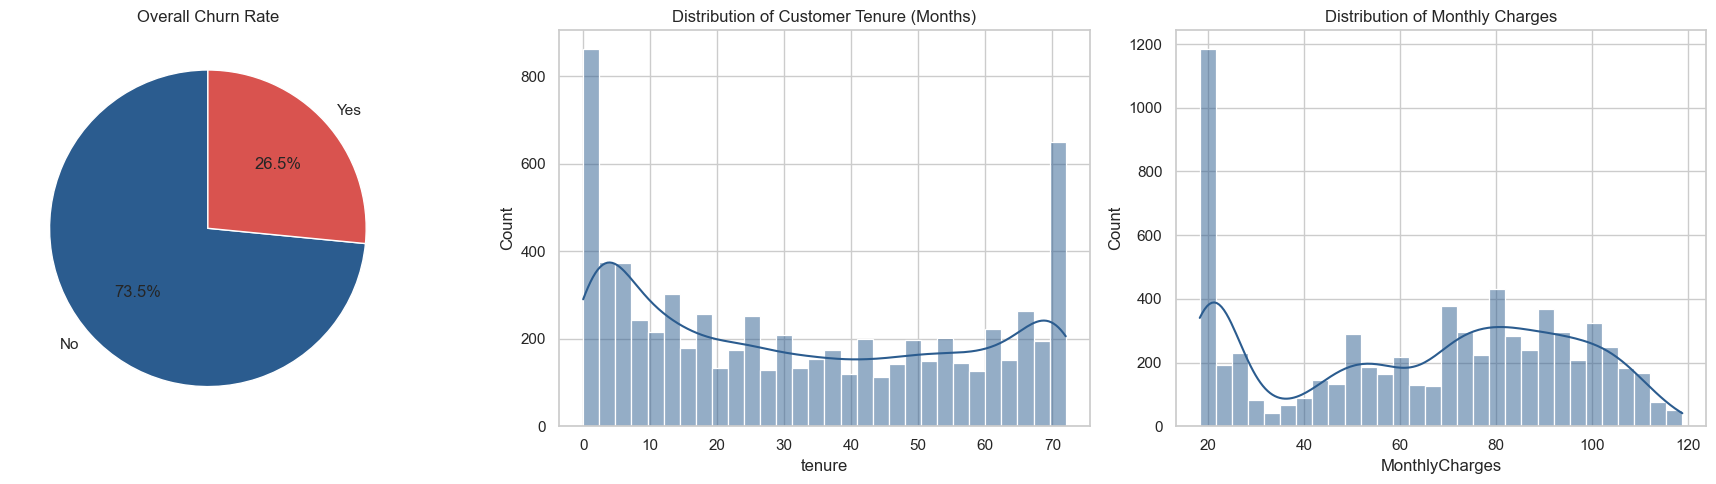

Churn Count & Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
# Create a figure with 2 subplots for Churn distribution and tenure/charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn Rate Pie Chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2b5c8f', '#d9534f'])
axes[0].set_title('Overall Churn Rate')

# 2. Tenure Distribution
sns.histplot(df['tenure'], kde=True, ax=axes[1], color='#2b5c8f', bins=30)
axes[1].set_title('Distribution of Customer Tenure (Months)')

# 3. Monthly Charges Distribution
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[2], color='#2b5c8f', bins=30)
axes[2].set_title('Distribution of Monthly Charges')

plt.tight_layout()
plt.show()

# Print exact percentages
print("Churn Count & Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

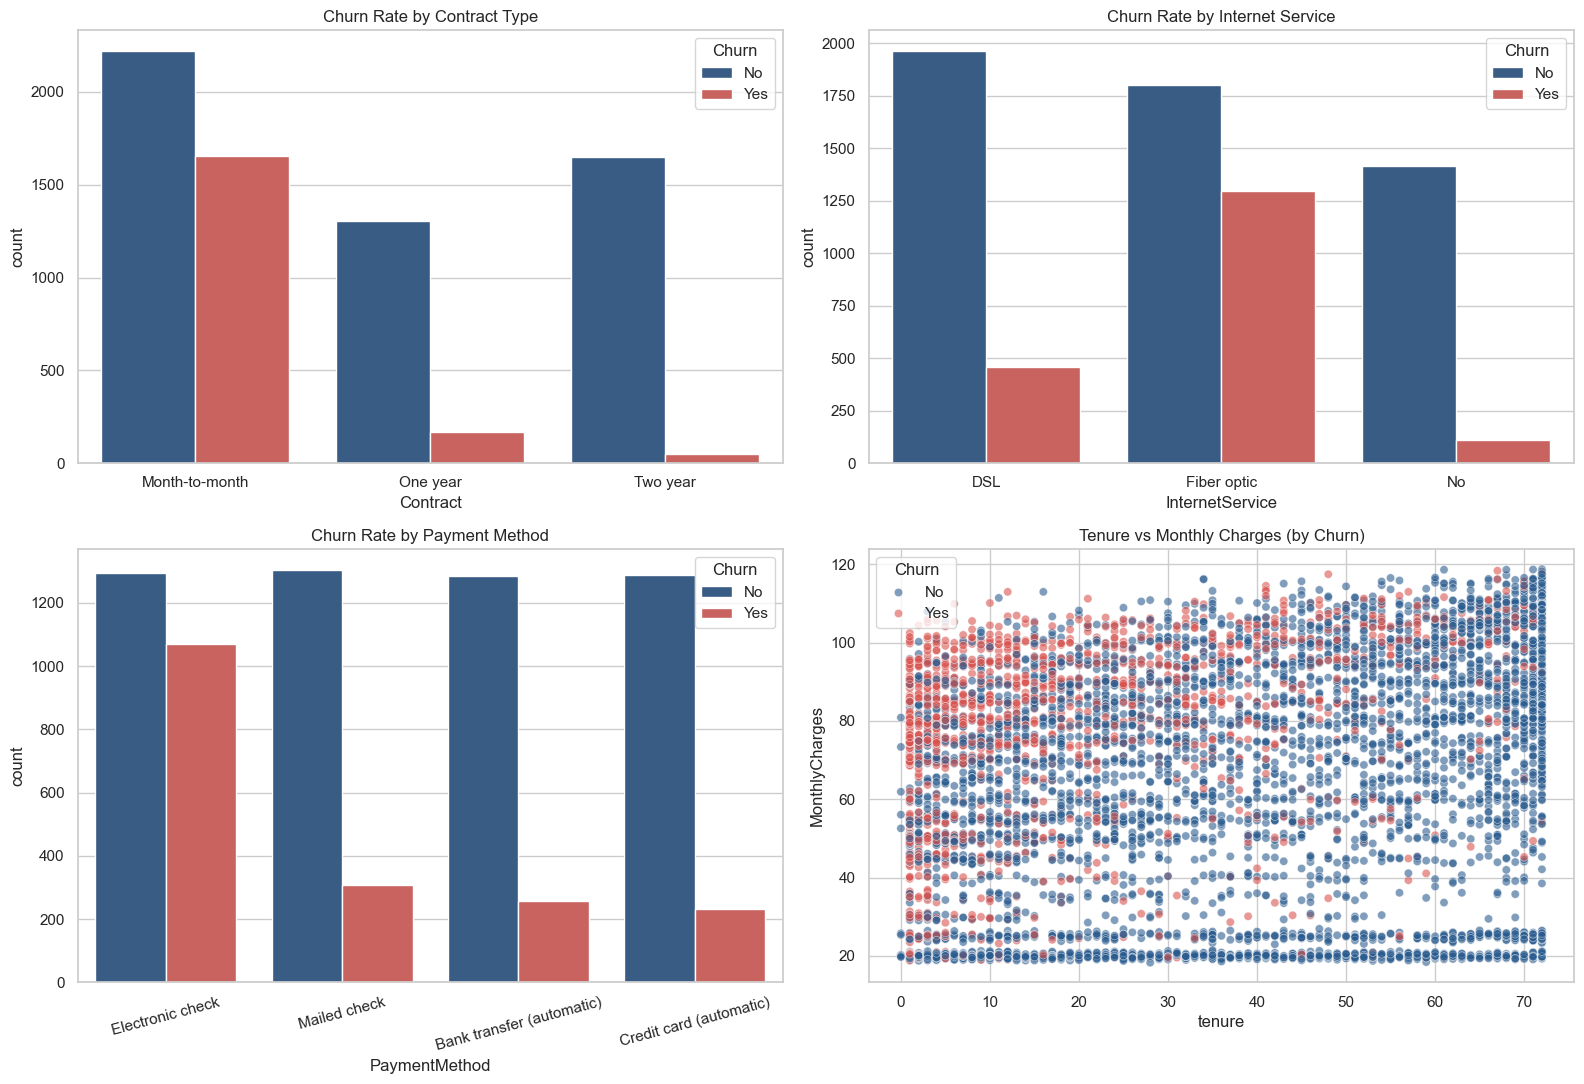

In [7]:
# Set up subplots for categorical feature comparison with Churn
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[0, 0])
axes[0, 0].set_title('Churn Rate by Contract Type')

# 2. Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[0, 1])
axes[0, 1].set_title('Churn Rate by Internet Service')

# 3. Churn by Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[1, 0])
axes[1, 0].set_title('Churn Rate by Payment Method')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Tenure vs Monthly Charges colored by Churn
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', palette=['#2b5c8f', '#d9534f'], alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Tenure vs Monthly Charges (by Churn)')

plt.tight_layout()
plt.show()

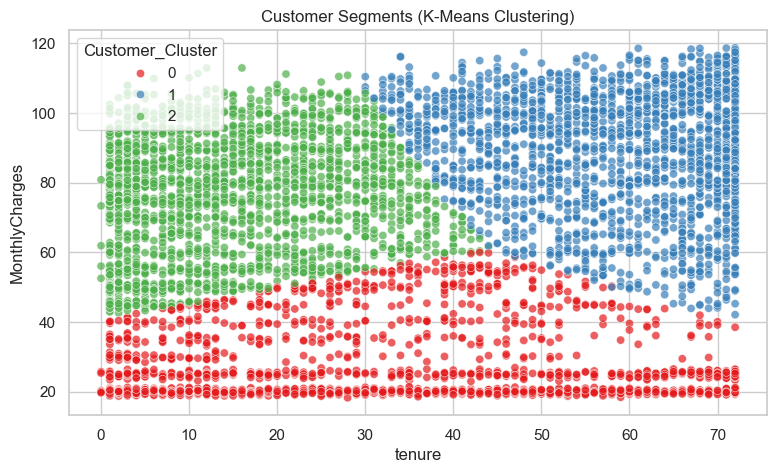

Cluster Summary:
                  tenure  MonthlyCharges  TotalCharges
Customer_Cluster                                      
0                  29.50           26.57        809.42
1                  58.56           89.70       5246.13
2                  13.25           74.95       1030.57


In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for segmentation
seg_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Standardize numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(seg_features)

# Apply K-Means Clustering (3 Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Customer_Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize Clusters
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Customer_Cluster', palette='Set1', alpha=0.7)
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

# Display mean stats for each cluster
print("Cluster Summary:")
print(df.groupby('Customer_Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2))

import warnings
warnings.filterwarnings('ignore')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Drop cluster column for ML model to prevent data leakage
ml_df = df.drop(columns=['Customer_Cluster'])

# Encode binary target
ml_df['Churn'] = ml_df['Churn'].map({'No': 0, 'Yes': 1})

# One-Hot Encoding for categorical variables
ml_df = pd.get_dummies(ml_df, drop_first=True)

# Separate Features and Target
X = ml_df.drop(columns=['Churn'])
y = ml_df['Churn']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8277


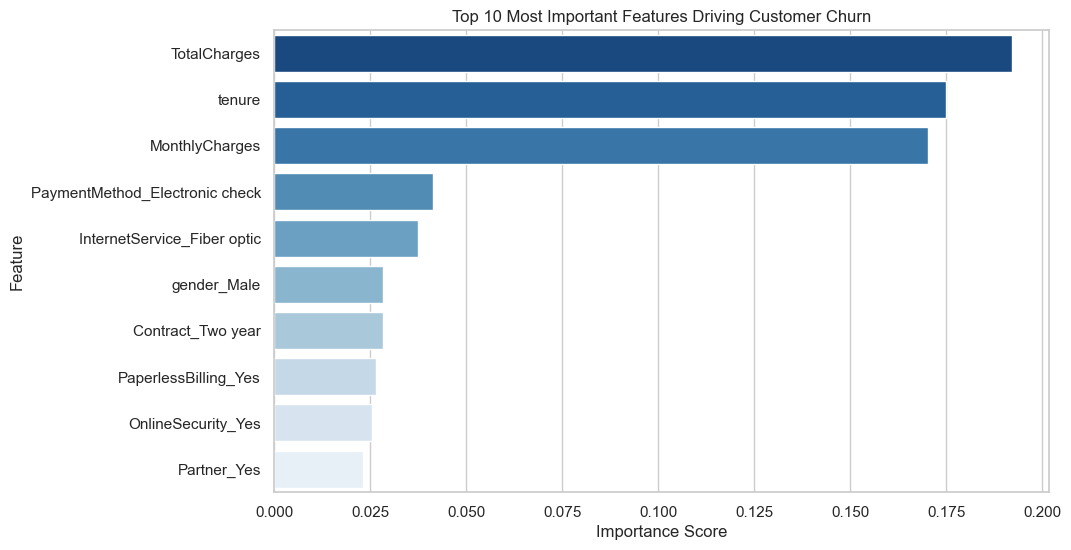

Top 5 Key Churn Drivers:
                       Feature  Importance
                  TotalCharges    0.192229
                        tenure    0.174901
                MonthlyCharges    0.170283
PaymentMethod_Electronic check    0.041393
   InternetService_Fiber optic    0.037420


In [11]:
# Extract feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame for top 10 important features
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 10 Most Important Features Driving Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Display Top Features
print("Top 5 Key Churn Drivers:")
print(feature_imp_df.head(5).to_string(index=False))